# Clustering

## 1. Librerías y configuraciones

In [2]:
import json
import random
from collections import Counter
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import HDBSCAN # Algoritmo de clustering sin necesidad de predefinir K
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from torch.utils.data import DataLoader

# Importaciones específicas para NLP/Clustering
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import TripletEvaluator


## 2. Configuraciones

In [43]:
# Rutas y entorno
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "1_Data" / "processed" / "clustering_data_cleaned.csv"
OUTPUT_DIR = BASE_DIR / "2_Modelos" / "clustering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [44]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [45]:
# Definir 2 modelos de Sentence-Transformers (Encoder) a comparar
MODELS_TO_COMPARE = {
    "distilbert": "distilbert-base-uncased",
    "minilm": "sentence-transformers/all-MiniLM-L6-v2", 
}

In [46]:
FINE_TUNING_CONFIG = {
    'batch_size': 16,
    'num_epochs': 3,
    'learning_rate': 2e-5,
    'warmup_steps': 100,
    'evaluation_steps': 50,
    'save_steps': 100,
    'max_seq_length': 256,
    'val_split': 0.2,
    'random_seed': RANDOM_SEED
}
MAX_OUTLIERS = 25

# Definir 3 configuraciones diferentes para el algoritmo de Clustering (HDBSCAN)
CONFIGS = {
    # Configuración conservadora (grupos grandes y limpios)
    "config_1": {
        "MIN_CLUSTER_SIZE": 15,
        "MIN_SAMPLES": 8,
        "METRIC": 'euclidean',
    },
    # Configuración más detallada (más clusters pequeños)
    "config_2": {
        "MIN_CLUSTER_SIZE": 5,
        "MIN_SAMPLES": 3,
        "METRIC": 'cosine',
    },
    # Configuración intermedia (balanceada)
    "config_3": {
        "MIN_CLUSTER_SIZE": 20,
        "MIN_SAMPLES": 10,
        "METRIC": 'euclidean',
    }
}

# Diccionario para almacenar resultados de todos los experimentos
all_results = {}


In [47]:
# Log de configuración
print("="*80)
print(f"DEVICE: {DEVICE} | SEED: {RANDOM_SEED}")
print(f"MODELOS A COMPARAR: {list(MODELS_TO_COMPARE.keys())}")
print(f"CONFIGURACIONES HDBSCAN: {list(CONFIGS.keys())}")
print("="*80)


DEVICE: cpu | SEED: 42
MODELOS A COMPARAR: ['distilbert', 'minilm']
CONFIGURACIONES HDBSCAN: ['config_1', 'config_2', 'config_3']


## 3. Carga y preparación de datos

In [48]:

def load_data(path: Path) -> pd.DataFrame:
    """Carga el archivo CSV y realiza una limpieza inicial."""
    df = pd.read_csv(path)
    required_cols = ['text', 'title', 'source']
    df = df.dropna(subset=required_cols)
    df['text'] = df['text'].astype(str)
    print(f"Datos cargados desde: {path}")
    print(f"Registros totales: {len(df)}")
    return df

df = load_data(DATA_PATH)
text_list = df['text'].tolist()


Datos cargados desde: /Users/arielamishaancohen/Documents/UVG/Clases/Semestre 8 (2025)/Deep Learning/Tareas y Proyectos/Proyecto/1_Data/processed/clustering_data_cleaned.csv
Registros totales: 434


### Train/Val

In [49]:
all_examples = []
source_groups = df.groupby('source')['text'].apply(list).to_dict()

for source, texts in source_groups.items():
    if len(texts) < 3: continue
    for i in range(len(texts)):
        for j in range(i+1, min(i+4, len(texts))): # Max 3 pares por texto
            all_examples.append(InputExample(texts=[texts[i], texts[j]], label=0.9))

train_size = int(len(all_examples) * (1 - FINE_TUNING_CONFIG['val_split']))
train_examples = all_examples[:train_size]
val_examples = all_examples[train_size:]

print(f"Pares de entrenamiento (Similarity): {len(train_examples)}")
print(f"Pares de validación (Similarity): {len(val_examples)}")


Pares de entrenamiento (Similarity): 621
Pares de validación (Similarity): 156


### Triplet Evaluator (para evaluar el Fine-Tuning)

In [50]:
source_to_texts = df.groupby('source')['text'].apply(list).to_dict()
sources = list(source_to_texts.keys())
anchors, positives, negatives = [], [], []

for source in sources:
    texts = source_to_texts[source]
    if len(texts) < 2: continue
    for i in range(min(5, len(texts))): 
        if i + 1 >= len(texts): break
        anchor = texts[i]
        positive = texts[i + 1]
        other_sources = [s for s in sources if s != source]
        if not other_sources: continue
        
        neg_source = random.choice(other_sources)
        if not source_to_texts[neg_source]: continue
        
        negative = random.choice(source_to_texts[neg_source])
        
        anchors.append(anchor)
        positives.append(positive)
        negatives.append(negative)

if len(anchors) == 0:
    print("No se pudieron crear triplets suficientes. Evaluación de fine-tuning desactivada.")
    evaluator = None 
else:
    print(f"Creados {len(anchors)} triplets para evaluación")
    evaluator = TripletEvaluator(anchors=anchors, positives=positives, negatives=negatives, name='validation', show_progress_bar=False)


Creados 212 triplets para evaluación


## 4. Función de entrenamiento

In [28]:
def run_experiment(model_key: str, model_name: str, config: Dict) -> Dict:
    """
    1. Fine-Tunes el modelo base.
    2. Genera los embeddings con el modelo fine-tuned.
    3. Aplica HDBSCAN para cada una de las 3 configuraciones.
    4. Guarda los resultados intermedios.
    """
    
    experiment_model_dir = OUTPUT_DIR / f"exp_model_{model_key}"
    experiment_model_dir.mkdir(exist_ok=True)
    
    print(f"\n{'='*80}\nMODELO: {model_key.upper()} ({model_name})\n{'='*80}")
    
    # --- PASO 1: FINE-TUNING ---
    ft_output_path = experiment_model_dir / "fine_tuned_model"
    
    try:
        # Cargar modelo base
        model = SentenceTransformer(model_name)
        model.to(DEVICE)
        
        # DataLoader y Loss
        train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=FINE_TUNING_CONFIG['batch_size'])
        train_loss = losses.MultipleNegativesRankingLoss(model)
        num_train_steps = len(train_dataloader) * FINE_TUNING_CONFIG['num_epochs']
        warmup_steps = min(FINE_TUNING_CONFIG['warmup_steps'], num_train_steps // 10)
        
        print(f"-> Iniciando Fine-Tuning (Steps: {num_train_steps}, Epochs: {FINE_TUNING_CONFIG['num_epochs']})")
        
        model.fit(
            train_objectives=[(train_dataloader, train_loss)],
            evaluator=evaluator,
            epochs=FINE_TUNING_CONFIG['num_epochs'],
            warmup_steps=warmup_steps,
            output_path=str(ft_output_path),
            show_progress_bar=False, # Desactivar para evitar LookupError
            evaluation_steps=FINE_TUNING_CONFIG['evaluation_steps'],
            save_best_model=True,
            optimizer_params={'lr': FINE_TUNING_CONFIG['learning_rate']},
        )
        
        # Cargar el mejor modelo fine-tuned para generar embeddings
        model = SentenceTransformer(str(ft_output_path))
        model.to(DEVICE)
        print("-> Fine-Tuning completado. Cargado el mejor modelo.")
        
    except Exception as e:
        print(f"\nError en Fine-Tuning para {model_key}: {str(e)}. Usando modelo base sin FT.")
        model = SentenceTransformer(model_name) # Si falla FT, usa el base pre-entrenado
        model.to(DEVICE)
        
    # --- PASO 2: GENERAR EMBEDDINGS ---
    print("-> Generando Embeddings...")
    embeddings_np = model.encode(
        text_list,
        batch_size=FINE_TUNING_CONFIG['batch_size'],
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True 
    )
    print(f"-> Embeddings generados: {embeddings_np.shape}")

    # Liberar modelo y caché de GPU antes del Clustering (Crítico para memoria)
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    
    # --- PASO 3: APLICAR CLUSTERING (3 configuraciones) ---
    model_results = {}
    
    for config_name, cluster_config in CONFIGS.items():
        experiment_key = f"{model_key}_{config_name}"
        print(f"\n--- INICIANDO {experiment_key} (MinSize: {cluster_config['MIN_CLUSTER_SIZE']}) ---")
        
        try:
            hdbscan = HDBSCAN(
                min_cluster_size=cluster_config["MIN_CLUSTER_SIZE"],
                min_samples=cluster_config["MIN_SAMPLES"],
                metric=cluster_config["METRIC"],
            )
            cluster_labels = hdbscan.fit_predict(embeddings_np)
            
            # Cálculo de Métricas (Solo puntos no-ruido)
            non_noise_indices = cluster_labels != -1
            labels_filtered = cluster_labels[non_noise_indices]
            embeddings_filtered = embeddings_np[non_noise_indices]
            n_clusters = len(np.unique(labels_filtered))
            n_noise = np.sum(cluster_labels == -1)

            if n_clusters < 2 or len(labels_filtered) < 2:
                s_score = -999.0
                db_score = 999.0
            else:
                s_score = silhouette_score(embeddings_filtered, labels_filtered)
                db_score = davies_bouldin_score(embeddings_filtered, labels_filtered)
            
            metrics = {
                "n_clusters": n_clusters,
                "n_noise_points": int(n_noise),
                "silhouette_score": float(s_score), # Métrica a maximizar
                "davies_bouldin_score": float(db_score),
            }

            all_results[experiment_key] = {
                "model_key": model_key,
                "model_name": model_name,
                "config_name": config_name,
                "config": cluster_config,
                "metrics": metrics,
                "cluster_labels": cluster_labels,
                "embeddings": embeddings_np, # Se usa para la exportación final
            }
            
            print(f"{experiment_key} completado. Silhouette: {s_score:.4f}, Clusters: {n_clusters}")
            
        except Exception as e:
            print(f"\nError en {experiment_key}: {str(e)}")
            continue

In [ ]:
def run_experiment(model_key: str, model_name: str, config: Dict) -> Dict:
    """
    1. Fine-Tunes el modelo base.
    2. Genera los embeddings con el modelo fine-tuned.
    3. Aplica HDBSCAN para cada una de las 3 configuraciones y limita outliers a MAX_OUTLIERS.
    4. Guarda los resultados intermedios.
    """
    
    experiment_model_dir = OUTPUT_DIR / f"exp_model_{model_key}"
    experiment_model_dir.mkdir(exist_ok=True)
    
    print(f"\n{'='*80}\nMODELO: {model_key.upper()} ({model_name})\n{'='*80}")
    
    # --- PASO 1: FINE-TUNING ---
    ft_output_path = experiment_model_dir / "fine_tuned_model"
    
    try:
        # Cargar modelo base
        model = SentenceTransformer(model_name)
        model.to(DEVICE)
        
        # DataLoader y Loss
        train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=FINE_TUNING_CONFIG['batch_size'])
        train_loss = losses.MultipleNegativesRankingLoss(model)
        num_train_steps = len(train_dataloader) * FINE_TUNING_CONFIG['num_epochs']
        warmup_steps = min(FINE_TUNING_CONFIG['warmup_steps'], num_train_steps // 10)
        
        print(f"-> Iniciando Fine-Tuning (Steps: {num_train_steps}, Epochs: {FINE_TUNING_CONFIG['num_epochs']})")
        
        model.fit(
            train_objectives=[(train_dataloader, train_loss)],
            evaluator=evaluator,
            epochs=FINE_TUNING_CONFIG['num_epochs'],
            warmup_steps=warmup_steps,
            output_path=str(ft_output_path),
            show_progress_bar=False,
            evaluation_steps=FINE_TUNING_CONFIG['evaluation_steps'],
            save_best_model=True,
            optimizer_params={'lr': FINE_TUNING_CONFIG['learning_rate']},
        )
        
        # Cargar el mejor modelo fine-tuned para generar embeddings
        model = SentenceTransformer(str(ft_output_path))
        model.to(DEVICE)
        print("-> Fine-Tuning completado. Cargado el mejor modelo.")
        
    except Exception as e:
        print(f"\nError en Fine-Tuning para {model_key}: {str(e)}. Usando modelo base sin FT.")
        model = SentenceTransformer(model_name)
        model.to(DEVICE)
        
    # --- PASO 2: GENERAR EMBEDDINGS ---
    print("-> Generando Embeddings...")
    embeddings_np = model.encode(
        text_list,
        batch_size=FINE_TUNING_CONFIG['batch_size'],
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True 
    )
    print(f"-> Embeddings generados: {embeddings_np.shape}")

    # Liberar modelo y caché de GPU antes del Clustering
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    
    # --- PASO 3: APLICAR CLUSTERING (3 configuraciones) y LIMITAR OUTLIERS ---
    
    for config_name, cluster_config in CONFIGS.items():
        experiment_key = f"{model_key}_{config_name}"
        print(f"\n--- INICIANDO {experiment_key} (MinSize: {cluster_config['MIN_CLUSTER_SIZE']}) ---")
        
        try:
            # 3.1. Aplicar HDBSCAN (Hard Clustering)
            hdbscan = HDBSCAN(
                min_cluster_size=cluster_config["MIN_CLUSTER_SIZE"],
                min_samples=cluster_config["MIN_SAMPLES"],
                metric=cluster_config["METRIC"],
            )
            
            cluster_labels_initial = hdbscan.fit_predict(embeddings_np)
            final_cluster_labels = cluster_labels_initial.copy()
            
            n_noise_initial = np.sum(final_cluster_labels == -1)
            
            # Verificar las probabilidades para la reasignación
            probabilities = hdbscan.probabilities_
            
            # 💡 FIX CLAVE: Comprobar la dimensión. Si es 1D, no hay clusters válidos para reasignar.
            has_valid_probabilities = probabilities.ndim == 2
            
            # 3.2. Proceso de REASIGNACIÓN de Outliers 🔄
            
            if n_noise_initial > MAX_OUTLIERS and has_valid_probabilities:
                print(f"Ruido inicial ({n_noise_initial}) > Máximo permitido ({MAX_OUTLIERS}). Reasignando...")
                
                outlier_indices = np.where(final_cluster_labels == -1)[0]
                num_to_reassign = n_noise_initial - MAX_OUTLIERS
                
                # Calcular la MÁXIMA probabilidad para cada outlier
                # Esto requiere un array 2D para usar axis=1, garantizado por has_valid_probabilities
                max_outlier_probs = np.max(probabilities[outlier_indices], axis=1)

                # Obtenemos los índices de los 'num_to_reassign' mejores candidatos (los menos ruidosos)
                best_candidates_indices_in_outlier_array = np.argsort(max_outlier_probs)[::-1][:num_to_reassign]
                
                # Obtenemos los índices originales (en embeddings_np) de los puntos a reasignar
                indices_to_reassign = outlier_indices[best_candidates_indices_in_outlier_array]

                # Reasignar estos puntos
                for idx in indices_to_reassign:
                    # Encontrar el índice (label) del cluster con la máxima probabilidad para ese punto
                    # np.argmax opera sobre la fila de probabilidades (que es 1D)
                    new_label = np.argmax(probabilities[idx]) 
                    final_cluster_labels[idx] = new_label 

                n_noise_final = np.sum(final_cluster_labels == -1)
                num_reasigned = num_to_reassign
                print(f"Reasignados {num_reasigned} puntos. Ruido final: {n_noise_final}")
                
            elif n_noise_initial > MAX_OUTLIERS and not has_valid_probabilities:
                n_noise_final = n_noise_initial
                num_reasigned = 0
                print(f"Ruido inicial ({n_noise_initial}) > Máximo permitido. NO se reasigna: No se formó ningún cluster válido.")
            else:
                n_noise_final = n_noise_initial
                num_reasigned = 0
                print(f"Ruido inicial ({n_noise_initial}) <= Máximo permitido ({MAX_OUTLIERS}). No se requiere reasignación.")

            # 3.3. Cálculo de Métricas con las etiquetas FINALES
            
            non_noise_indices = final_cluster_labels != -1
            labels_filtered = final_cluster_labels[non_noise_indices]
            embeddings_filtered = embeddings_np[non_noise_indices]
            
            n_clusters = len(np.unique(labels_filtered)) if len(labels_filtered) > 0 else 0

            if n_clusters < 2 or len(labels_filtered) < 2:
                s_score = -999.0
                db_score = 999.0
            else:
                s_score = silhouette_score(embeddings_filtered, labels_filtered)
                db_score = davies_bouldin_score(embeddings_filtered, labels_filtered)
            
            metrics = {
                "n_clusters": n_clusters,
                "n_noise_points": int(n_noise_final),
                "silhouette_score": float(s_score), 
                "davies_bouldin_score": float(db_score),
                "reasigned_points": int(num_reasigned) 
            }

            all_results[experiment_key] = {
                "model_key": model_key,
                "model_name": model_name,
                "config_name": config_name,
                "config": cluster_config,
                "metrics": metrics,
                "cluster_labels": final_cluster_labels,
                "embeddings": embeddings_np, 
            }
            
            print(f"{experiment_key} completado. Silhouette: {s_score:.4f}, Clusters: {n_clusters}")
            
        except Exception as e:
            print(f"\nError en {experiment_key}: {str(e)}")
            continue

## 5. Ejecución de entrenamiento

In [58]:
for model_key, model_name in MODELS_TO_COMPARE.items():
    run_experiment(model_key, model_name, CONFIGS)


MODELO: DISTILBERT (distilbert-base-uncased)


No sentence-transformers model found with name distilbert-base-uncased. Creating a new one with mean pooling.


-> Iniciando Fine-Tuning (Steps: 117, Epochs: 3)


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/Users/arielamishaancohen/Library/Python/3.10/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/Users/arielamishaancohen/Library/Python/3.10/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_validation_cosine_accuracy': 0.7735849022865295, 'eval_runtime': 0.7636, 'eval_samples_per_second': 0.0, 'eval_steps_per_second': 0.0, 'epoch': 1.282051282051282}
{'eval_validation_cosine_accuracy': 0.8066037893295288, 'eval_runtime': 0.7122, 'eval_samples_per_second': 0.0, 'eval_steps_per_second': 0.0, 'epoch': 2.564102564102564}
{'train_runtime': 27.2624, 'train_samples_per_second': 68.336, 'train_steps_per_second': 4.292, 'train_loss': 2.9661189674312234, 'epoch': 3.0}
-> Fine-Tuning completado. Cargado el mejor modelo.
-> Generando Embeddings...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

-> Embeddings generados: (434, 384)

--- INICIANDO minilm_config_1 (MinSize: 15) ---
   ⚠️ Ruido inicial (434) > Máximo permitido. NO se reasigna: No se formó ningún cluster válido.
✅ minilm_config_1 completado. Silhouette: -999.0000, Clusters: 0

--- INICIANDO minilm_config_2 (MinSize: 5) ---
   ⚠️ Ruido inicial (334) > Máximo permitido. NO se reasigna: No se formó ningún cluster válido.
✅ minilm_config_2 completado. Silhouette: 0.1168, Clusters: 8

--- INICIANDO minilm_config_3 (MinSize: 20) ---
   ⚠️ Ruido inicial (434) > Máximo permitido. NO se reasigna: No se formó ningún cluster válido.
✅ minilm_config_3 completado. Silhouette: -999.0000, Clusters: 0


## 6. Evaluación y exportación

In [59]:
def evaluate_and_export_best(df: pd.DataFrame, all_results: Dict, output_dir: Path):
    """Selecciona el mejor experimento y exporta los resultados."""
    
    if not all_results:
        print("\n❌ No se pudo completar ningún experimento. No se puede exportar.")
        return

    # 1. Consolidar resultados y seleccionar el mejor
    
    # Crea un diccionario a partir de all_results, donde la clave (k) del experimento
    # se mantiene como índice.
    df_results_summary = pd.DataFrame.from_dict({
        k: {
            **v['config'], 
            **v['metrics'], 
            'model_key': v['model_key'],
        } 
        for k, v in all_results.items()
    }, orient='index').reset_index(names=['experiment_key'])
    # NOTA: Al usar reset_index(), el índice (que era la clave 'experiment_key') 
    # se convierte en una columna llamada 'experiment_key' sin duplicados.
    
    # Seleccionar el mejor: Maximizando Silhouette Score
    best_experiment_key = df_results_summary.loc[df_results_summary['silhouette_score'].idxmax(), 'experiment_key']
    best_model_data = all_results[best_experiment_key]
    
    # Guardar la tabla de comparación
    output_summary_path = output_dir / "clustering_model_comparison.csv"
    df_results_summary.to_csv(output_summary_path, index=False)
    
    # 2. Exportar el DataFrame final del mejor modelo
    best_cluster_labels = best_model_data['cluster_labels']
    best_embeddings = best_model_data['embeddings']
    
    # Aplicar PCA para la visualización (exacto al script original)
    pca_export = PCA(n_components=2, random_state=RANDOM_SEED)
    embeddings_2d_export = pca_export.fit_transform(best_embeddings)
    
    # Crear y exportar DataFrame final
    df_results = df.copy()
    df_results['cluster_label'] = best_cluster_labels
    df_results['pca_dim_1'] = embeddings_2d_export[:, 0]
    df_results['pca_dim_2'] = embeddings_2d_export[:, 1]
    
    # Exportar a CSV (mismas columnas que el script original)
    output_csv_path = output_dir / "clustering_results_consolidated.csv"
    df_results[['text', 'title', 'source', 'cluster_label', 'pca_dim_1', 'pca_dim_2']].to_csv(
        output_csv_path, 
        index=False, 
        encoding='utf-8'
    )
    
    # 3. Guardar la configuración del mejor experimento
    best_config_to_save = {
        'fine_tuning_config': FINE_TUNING_CONFIG,
        'best_clustering_config': best_model_data['config'],
        'model_name': best_model_data['model_name'],
        'experiment_key': best_experiment_key,
        'metrics': best_model_data['metrics']
    }
    with open(output_dir / "best_clustering_config_and_metrics.json", 'w') as f:
        json.dump(best_config_to_save, f, indent=2)

    # 4. Mostrar Resumen
    print("\n" + "="*80)
    print("MEJOR MODELO SELECCIONADO Y RESULTADOS EXPORTADOS")
    print("="*80)
    print(f"Mejor Experimento: {best_experiment_key.upper()}")
    print(f"  - Modelo: {best_model_data['model_name']}")
    print(f"  - Configuración HDBSCAN: {best_model_data['config_name']}")
    print(f"  - Silhouette Score (Max): {best_model_data['metrics']['silhouette_score']:.4f}")
    
    print("\nArchivos generados:")
    print(f"  -> {output_summary_path}")
    print(f"  -> {output_csv_path}")


RESUMEN DE MÉTRICAS DE CLUSTERING (6 Experimentos)


,experiment_key,model_key,MIN_CLUSTER_SIZE,METRIC,Clusters (#),Ruido (#),Silhouette (MAX),DB Index (MIN)
0,distilbert_config_1,distilbert,15,euclidean,5,268,0.340083,1.186078
2,distilbert_config_3,distilbert,20,euclidean,4,245,0.269311,1.461719
1,distilbert_config_2,distilbert,5,cosine,14,195,0.221670,1.414908
4,minilm_config_2,minilm,5,cosine,8,334,0.116820,2.002648
3,minilm_config_1,minilm,15,euclidean,0,434,-999.000000,999.000000
5,minilm_config_3,minilm,20,euclidean,0,434,-999.000000,999.000000



✓ Gráfico de comparación guardado en: /Users/arielamishaancohen/Documents/UVG/Clases/Semestre 8 (2025)/Deep Learning/Tareas y Proyectos/Proyecto/2_Modelos/clustering/clustering_model_comparison_plot.png


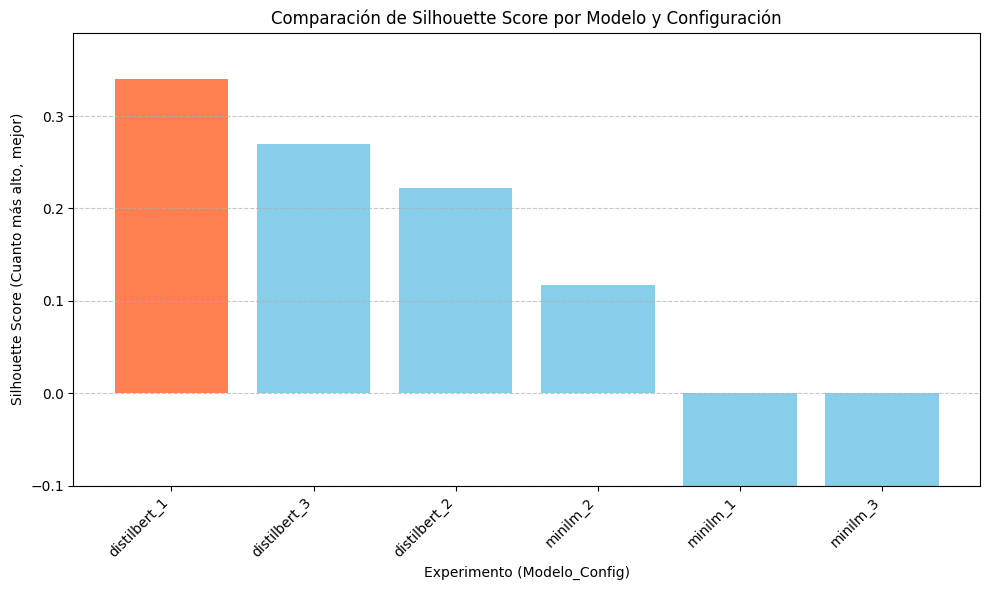

In [60]:
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("RESUMEN DE MÉTRICAS DE CLUSTERING (6 Experimentos)")
print("="*80)

if not all_results:
    print("❌ No se registraron resultados de experimentos.")
else:
    # 1. Consolidar resultados en un DataFrame
    df_results_summary = pd.DataFrame.from_dict({
        k: {
            **v['config'], 
            **v['metrics'], 
            'model_key': v['model_key'],
        } 
        for k, v in all_results.items()
    }, orient='index').reset_index(names=['experiment_key'])

    # 2. Renombrar y ordenar para visualización
    df_results_summary = df_results_summary.rename(columns={
        'silhouette_score': 'Silhouette (MAX)',
        'davies_bouldin_score': 'DB Index (MIN)',
        'n_clusters': 'Clusters (#)',
        'n_noise_points': 'Ruido (#)',
    })
    
    df_summary_display = df_results_summary[[
        'experiment_key', 'model_key', 'MIN_CLUSTER_SIZE', 'METRIC', 
        'Clusters (#)', 'Ruido (#)', 'Silhouette (MAX)', 'DB Index (MIN)'
    ]].sort_values(by='Silhouette (MAX)', ascending=False)
    
    # Mostrar la tabla
    from IPython.display import display
    display(df_summary_display)
    
    # 3. Generar el PLOT de Silhouette Score
    
    plt.figure(figsize=(10, 6))
    
    # Generar etiquetas para el eje X
    plot_labels = [f"{row['model_key']}_{row['experiment_key'].split('_')[-1]}" for index, row in df_summary_display.iterrows()]
    
    # Obtener los valores de Silhouette
    silhouette_values = df_summary_display['Silhouette (MAX)'].values
    
    # Asignar un color diferente al mejor modelo (primera fila)
    colors = ['skyblue'] * len(plot_labels)
    colors[0] = 'coral' # El mejor experimento en coral

    plt.bar(plot_labels, silhouette_values, color=colors)
    plt.title('Comparación de Silhouette Score por Modelo y Configuración')
    plt.xlabel('Experimento (Modelo_Config)')
    plt.ylabel('Silhouette Score (Cuanto más alto, mejor)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(max(-0.1, min(silhouette_values) - 0.05), max(silhouette_values) + 0.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Guardar el plot
    plot_path = OUTPUT_DIR / 'clustering_model_comparison_plot.png'
    plt.savefig(plot_path)
    print(f"\n✓ Gráfico de comparación guardado en: {plot_path}")
    
    # Mostrar el plot en el notebook
    plt.show()

print("\n")

In [61]:
evaluate_and_export_best(df, all_results, OUTPUT_DIR)


MEJOR MODELO SELECCIONADO Y RESULTADOS EXPORTADOS
Mejor Experimento: DISTILBERT_CONFIG_1
  - Modelo: distilbert-base-uncased
  - Configuración HDBSCAN: config_1
  - Silhouette Score (Max): 0.3401

Archivos generados:
  -> /Users/arielamishaancohen/Documents/UVG/Clases/Semestre 8 (2025)/Deep Learning/Tareas y Proyectos/Proyecto/2_Modelos/clustering/clustering_model_comparison.csv
  -> /Users/arielamishaancohen/Documents/UVG/Clases/Semestre 8 (2025)/Deep Learning/Tareas y Proyectos/Proyecto/2_Modelos/clustering/clustering_results_consolidated.csv
